In [1]:
# 1. Unzip your specific file into a folder called 'my_data'
!unzip -q "plant disease.zip" -d my_data

# 2. Run this search tool to find exactly where your Tomato folders are hidden
import os
def find_tomato_path(start_dir):
    for root, dirs, files in os.walk(start_dir):
        if 'Tomato_Bacterial_spot' in dirs:
            return root
    return None

detected_path = find_tomato_path('/content/my_data')
print(f"\nYour exact data folder path is: {detected_path}")


Your exact data folder path is: /content/my_data/plant disease/PlantVillage


In [2]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

# Define the image cleaning settings
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Use the path found in Step 3 automatically
data_dir = detected_path

dataset = datasets.ImageFolder(data_dir, transform=transform)

# Split the dataset: 80% for training the models, 20% for testing their final accuracy
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_data, test_data = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

print(f"Success! Found {len(dataset)} images across {len(dataset.classes)} tomato disease categories.")

Success! Found 18700 images across 6 tomato disease categories.


In [3]:
import torchvision.models as models
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. ResNet50
resnet = models.resnet50(pretrained=True)
resnet.fc = nn.Linear(resnet.fc.in_features, 6)

# 2. GoogLeNet
googlenet = models.googlenet(pretrained=True)
googlenet.fc = nn.Linear(googlenet.fc.in_features, 6)

# 3. SqueezeNet
squeezenet = models.squeezenet1_0(pretrained=True)
squeezenet.classifier[1] = nn.Conv2d(512, 6, kernel_size=(1,1))

# 4. AlexNet
alexnet = models.alexnet(pretrained=True)
alexnet.classifier[6] = nn.Linear(alexnet.classifier[6].in_features, 6)

# Move them all to your active T4 GPU
resnet, googlenet, squeezenet, alexnet = resnet.to(device), googlenet.to(device), squeezenet.to(device), alexnet.to(device)

print("All 4 models successfully customized and loaded onto the GPU!")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 147MB/s]
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=GoogLeNet_Weights.IMAGENET1K_V1`. You can also use `weights=GoogLeNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/googlenet-1378be20.pth" to /root/.cache/torch/hub/checkpoints/googlenet-1378be20.pth


100%|██████████| 49.7M/49.7M [00:00<00:00, 168MB/s]
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=SqueezeNet1_0_Weights.IMAGENET1K_V1`. You can also use `weights=SqueezeNet1_0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/squeezenet1_0-b66bff10.pth" to /root/.cache/torch/hub/checkpoints/squeezenet1_0-b66bff10.pth


100%|██████████| 4.78M/4.78M [00:00<00:00, 150MB/s]
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 174MB/s]


All 4 models successfully customized and loaded onto the GPU!


In [7]:
import torch.optim as optim
import time

def train_and_evaluate(model, model_name):
    print(f"\n================ Starting Training: {model_name} ================")
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    start_time = time.time()

    for epoch in range(5): # The model will look at the entire dataset 5 times
        model.train()
        running_loss = 0.0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        print(f"Epoch {epoch+1}/5 - Loss: {running_loss/len(train_loader):.4f}")

    training_time = time.time() - start_time
    print(f"Finished training {model_name} in {training_time:.2f} seconds.")
    return training_time

In [8]:
# Run the training function for ResNet50
resnet_time = train_and_evaluate(resnet, "ResNet50")


================ Starting Training: ResNet50 ================
Epoch 1/5 - Loss: 0.8716
Epoch 2/5 - Loss: 0.7321
Epoch 3/5 - Loss: 0.6876
Epoch 4/5 - Loss: 0.6666
Epoch 5/5 - Loss: 0.6407
Finished training ResNet50 in 903.03 seconds.


In [9]:
googlenet_time = train_and_evaluate(googlenet, "GoogLeNet")


================ Starting Training: GoogLeNet ================
Epoch 1/5 - Loss: 0.7452
Epoch 2/5 - Loss: 0.6570
Epoch 3/5 - Loss: 0.6420
Epoch 4/5 - Loss: 0.6141
Epoch 5/5 - Loss: 0.6141
Finished training GoogLeNet in 453.23 seconds.


In [10]:
def calculate_accuracy(model, model_name):
    model.eval()  # Set the model to evaluation mode
    correct = 0
    total = 0
    with torch.no_grad():  # Turn off gradient tracking to go fast
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f"{model_name} Final Test Accuracy: {accuracy:.2f}%")
    return accuracy

In [11]:
# 1. Compute the accuracy scores using the function above
resnet_acc = calculate_accuracy(resnet, "ResNet50")
googlenet_acc = calculate_accuracy(googlenet, "GoogLeNet")

# 2. Print your beautiful comparative analysis table
print("\n" + "="*70)
print(f"{'TOMATO LEAF DISEASE DETECTION MODEL COMPARISON':^70}")
print("="*70)
print(f" {'Model Name':<15} | {'Training Time (Seconds)':<25} | {'Test Accuracy (%)':<20}")
print("-"*70)
print(f" ResNet50       | {resnet_time:<25.2f} | {resnet_acc:<20.2f}%")
print(f" GoogLeNet      | {googlenet_time:<25.2f} | {googlenet_acc:<20.2f}%")
print("="*70)

ResNet50 Final Test Accuracy: 58.34%
GoogLeNet Final Test Accuracy: 56.68%

            TOMATO LEAF DISEASE DETECTION MODEL COMPARISON            
 Model Name      | Training Time (Seconds)   | Test Accuracy (%)   
----------------------------------------------------------------------
 ResNet50       | 903.03                    | 58.34               %
 GoogLeNet      | 453.23                    | 56.68               %


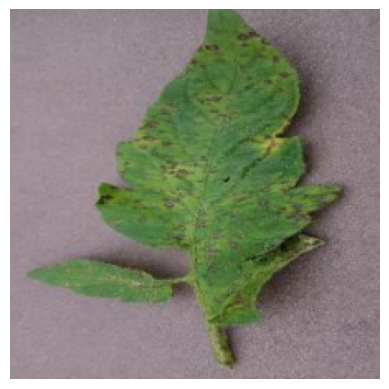

🌿 Actual Disease:      Tomato_Septoria_leaf_spot
🤖 ResNet50 Predicted:   Tomato_Septoria_leaf_spot
🤖 GoogLeNet Predicted:  Tomato_Septoria_leaf_spot


In [12]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Grab a random batch of images from your test data
images, labels = next(iter(test_loader))

# 2. Pick the very first image from that batch
test_image = images[0].unsqueeze(0).to(device)
true_label = labels[0].item()

# 3. Get predictions from both models
resnet.eval()
googlenet.eval()
with torch.no_grad():
    res_out = resnet(test_image)
    goog_out = googlenet(test_image)

    _, res_pred = torch.max(res_out, 1)
    _, goog_pred = torch.max(goog_out, 1)

# 4. Convert the image back to normal colors so we can look at it
inv_normalize = transforms.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std=[1/0.229, 1/0.224, 1/0.225]
)
input_img = inv_normalize(images[0]).permute(1, 2, 0).numpy()
input_img = np.clip(input_img, 0, 1)

# 5. Display the image and the results
plt.imshow(input_img)
plt.axis('off')
plt.show()

# Get the folder/class names
class_names = dataset.classes

print(f"🌿 Actual Disease:      {class_names[true_label]}")
print(f"🤖 ResNet50 Predicted:   {class_names[res_pred.item()]}")
print(f"🤖 GoogLeNet Predicted:  {class_names[goog_pred.item()]}")


--- TEST 1: HEALTHY LEAF ---
🌿 Actual Class:       Tomato_healthy
🤖 ResNet50 Predicted:  Tomato_healthy
🤖 GoogLeNet Predicted: Tomato_Septoria_leaf_spot

--- TEST 2: DISEASED LEAF ---
🌿 Actual Class:       Tomato_Leaf_Mold
🤖 ResNet50 Predicted:  Tomato_Leaf_Mold
🤖 GoogLeNet Predicted: Tomato_Leaf_Mold


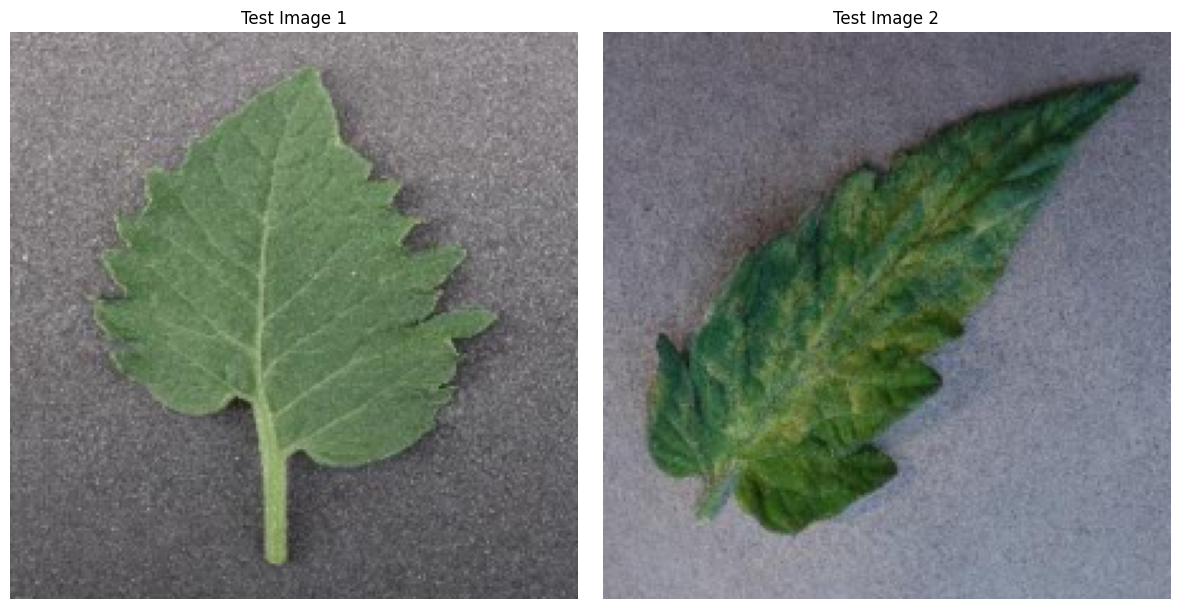

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# 1. Get the list of all category names from your dataset
class_names = dataset.classes

# 2. Find indices for a healthy leaf and a diseased leaf in the test dataset
healthy_idx = None
other_disease_idx = None

for idx in range(len(test_data)):
    _, label_idx = test_data[idx]
    class_name = class_names[label_idx]

    # Look for a healthy tomato leaf
    if 'healthy' in class_name.lower() and healthy_idx is None:
        healthy_idx = idx
    # Look for a different disease (not healthy, and not Septoria which we already saw)
    elif 'healthy' not in class_name.lower() and 'septoria' not in class_name.lower() and other_disease_idx is None:
        other_disease_idx = idx

    # Stop searching once we find both
    if healthy_idx is not None and other_disease_idx is not None:
        break

# 3. Create a helper function to test and plot an image
def display_prediction(dataset_idx, title_prefix):
    image_tensor, true_label = test_data[dataset_idx]
    test_image = image_tensor.unsqueeze(0).to(device)

    # Get predictions
    resnet.eval()
    googlenet.eval()
    with torch.no_grad():
        res_out = resnet(test_image)
        goog_out = googlenet(test_image)
        _, res_pred = torch.max(res_out, 1)
        _, goog_pred = torch.max(goog_out, 1)

    # Fix colors for plotting
    inv_normalize = transforms.Normalize(
        mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
        std=[1/0.229, 1/0.224, 1/0.225]
    )
    input_img = inv_normalize(image_tensor).permute(1, 2, 0).numpy()
    input_img = np.clip(input_img, 0, 1)

    # Print the text results clearly
    print(f"\n--- {title_prefix} ---")
    print(f"🌿 Actual Class:       {class_names[true_label]}")
    print(f"🤖 ResNet50 Predicted:  {class_names[res_pred.item()]}")
    print(f"🤖 GoogLeNet Predicted: {class_names[goog_pred.item()]}")

    return input_img

# 4. Run it and plot them side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

if healthy_idx is not None:
    img_healthy = display_prediction(healthy_idx, "TEST 1: HEALTHY LEAF")
    axes[0].imshow(img_healthy)
    axes[0].set_title("Test Image 1")
    axes[0].axis('off')
else:
    print("Could not find a 'healthy' leaf in the test split.")

if other_disease_idx is not None:
    img_disease = display_prediction(other_disease_idx, "TEST 2: DISEASED LEAF")
    axes[1].imshow(img_disease)
    axes[1].set_title("Test Image 2")
    axes[1].axis('off')
else:
    print("Could not find another disease type in the test split.")

plt.tight_layout()
plt.show()


================ TEST 3: NEW DISEASE DETECTION ================
🌿 Actual Disease Name:  Tomato_Late_blight
🤖 ResNet50 Predicted:   Tomato_Septoria_leaf_spot
🤖 GoogLeNet Predicted:  Tomato_Septoria_leaf_spot


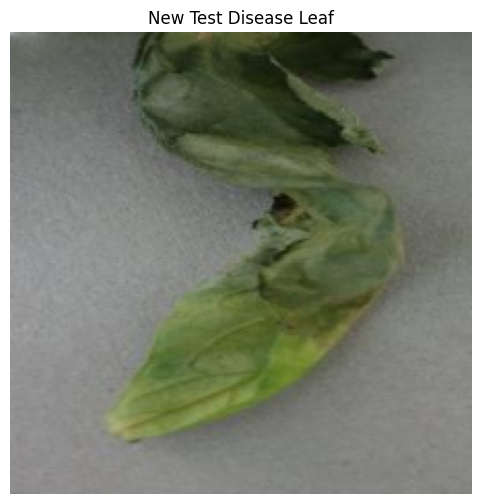

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# 1. Get the list of all category names
class_names = dataset.classes

# 2. Find a new disease that we haven't checked yet
# (Not healthy, not Septoria, and not the one from your previous test)
already_seen = ['healthy', 'septoria']
# Let's see if we can find what the last disease was to exclude it too
if 'other_disease_idx' in locals() and other_disease_idx is not None:
    last_disease_name = class_names[test_data[other_disease_idx][1]].lower()
    already_seen.append(last_disease_name)

new_disease_idx = None
for idx in range(len(test_data)):
    _, label_idx = test_data[idx]
    class_name = class_names[label_idx].lower()

    # Check if this is a disease we haven't looked at yet
    if not any(seen in class_name for seen in already_seen):
        new_disease_idx = idx
        break

# 3. Test and display the new disease
if new_disease_idx is not None:
    image_tensor, true_label = test_data[new_disease_idx]
    test_image = image_tensor.unsqueeze(0).to(device)

    # Get predictions
    resnet.eval()
    googlenet.eval()
    with torch.no_grad():
        res_out = resnet(test_image)
        goog_out = googlenet(test_image)
        _, res_pred = torch.max(res_out, 1)
        _, goog_pred = torch.max(goog_out, 1)

    # Fix colors for plotting
    inv_normalize = transforms.Normalize(
        mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
        std=[1/0.229, 1/0.224, 1/0.225]
    )
    input_img = inv_normalize(image_tensor).permute(1, 2, 0).numpy()
    input_img = np.clip(input_img, 0, 1)

    # Print results
    print("\n================ TEST 3: NEW DISEASE DETECTION ================")
    print(f"🌿 Actual Disease Name:  {class_names[true_label]}")
    print(f"🤖 ResNet50 Predicted:   {class_names[res_pred.item()]}")
    print(f"🤖 GoogLeNet Predicted:  {class_names[goog_pred.item()]}")
    print("================================================================")

    # Show the image
    plt.figure(figsize=(6, 6))
    plt.imshow(input_img)
    plt.axis('off')
    plt.title("New Test Disease Leaf")
    plt.show()
else:
    print("No more unique disease categories found in your test dataset split!")